In [2]:
%pip install matplotlib
%pip install scqubits
%matplotlib inline
import scqubits as scq

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install ipyvuetify
scq.GUI()

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Container(children=[Sheet(children=[Card(children=[Img(layout=None, src='data:image/png;base64,iVBORw0KGgoAAAA…

In [120]:
import matplotlib.pyplot as plt
from sympy.physics.quantum import Ket, Bra
from sympy import symbols
import math

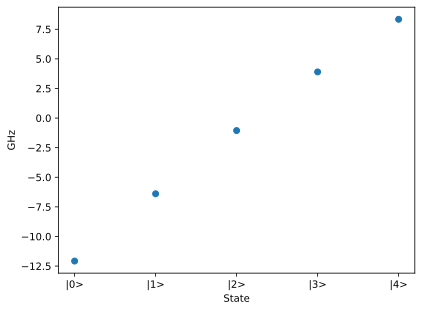

In [ ]:
Ej = 15
Ec = 0.3
n = 30
ng = 0

transmon = scq.Transmon(Ej, Ec, ng, n)
eigs = transmon.eigenvals(evals_count = 5)

index = []
tick_labels = []
for i in range(len(eigs)):
    index.append(i)
    tick_labels.append(Ket(i))

fig, ax = plt.subplots()

plt.scatter(index, eigs)
plt.xlabel('State')
plt.ylabel('GHz')

ax.set_xticks(index)
ax.set_xticklabels(tick_labels)

plt.show()

Text(0, 0.5, 'GHz')

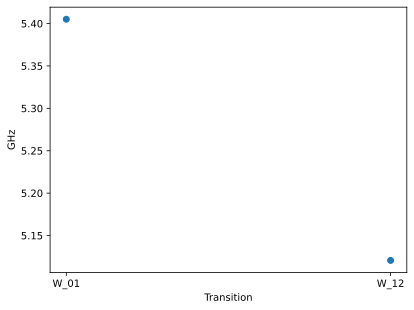

In [ ]:
h = 6.626 #* 10**-34
hbar = h/(2*math.pi)

W01 = 1/hbar * ((8*Ej*Ec)**0.5 - Ec)
W12 = 1/hbar * ((8*Ej*Ec)**0.5 - 2 * Ec)

diff01 = W01 - abs(eigs[0]-eigs[1])
diff12 = W12 - abs(eigs[1]-eigs[2])

W = [W01, W12]
diff = [diff01, diff12]

Anharm = W12- W01
Pred_anharm = -Ec/hbar

Anharm_diff = Anharm-Pred_anharm

fig, ax = plt.subplots()

labels = ["W_01", "W_12"]

ax.set_xticks([1,2])
ax.set_xticklabels(labels)

plt.scatter([1,2],W)
plt.xlabel('Transition')
plt.ylabel('GHz')


In [13]:
Ej2 = 20
Ec2 = 0.24
n2 = 30
ng2 = 0

transmon2 = scq.Transmon(Ej2, Ec2, ng2, n2)
ham = transmon2.hamiltonian()
print(ham)
eigs = transmon2.eigensys(evals_count=(5))
#matrix = transmon2.matrixelement_table('n_operator', evals_count=(2*n2+1))

# for i in range(0,10):
#      n_g = i/10
#      trans = scq.Transmon(Ej2,Ec2, n_g, n2)
#      print(trans.matrixelement_table('n_operator', evals_count=(2*n2+1))[0])
# #matrix[0]

eigs[0][0] - eigs[0][1]


[[864.   -10.     0.   ...   0.     0.     0.  ]
 [-10.   807.36 -10.   ...   0.     0.     0.  ]
 [  0.   -10.   752.64 ...   0.     0.     0.  ]
 ...
 [  0.     0.     0.   ... 752.64 -10.     0.  ]
 [  0.     0.     0.   ... -10.   807.36 -10.  ]
 [  0.     0.     0.   ...   0.   -10.   864.  ]]


np.float64(-5.946372751717497)

In [12]:
%pip install qutip
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML
from qutip import (ket, basis, tensor, sigmaz, qeye, mesolve, anim_schmidt,
                   complex_array_to_rgb, spin_q_function,
                   anim_spin_distribution, about)

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


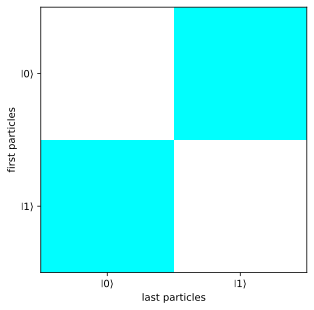

In [14]:
# Hamiltonian
H = tensor(sigmaz(), qeye(2))

# initial state
psi0 = (ket('10')+ket('01')).unit()

# list of times for which the solver should store the state vector
tlist = np.linspace(0, 3*np.pi, 100)

results = mesolve(H, psi0, tlist, [], e_ops=[])

fig, ani = anim_schmidt(results)

HTML(ani.to_jshtml())


In [68]:
import qutip as qt
import scqubits as scq

# 1. Create a Transmon and a Resonator
trans1 = scq.Transmon(EJ=15.0, EC=0.3, ng=0.0, ncut=3)
trans2 = scq.Transmon(EJ=10.0, EC=0.3, ng=0.0, ncut=3)
#resonator = scq.Oscillator(E_osc=5.0, truncated_dim=10)

# 2. Build the coupled Hilbert space
Q_obj = scq.HilbertSpace([trans1, trans2])

# Get the Hamiltonian as a QuTiP Qobj
h_qobj = Q_obj.hamiltonian()

h_qobj[0]

#h_qobj.eigenenergies()

#the "hamiltonian" is not a hamiltonian but actually a matrix of the eigenvalues of the hilbert space

array([[-19.66857142+0.j,   0.        +0.j,   0.        +0.j,
          0.        +0.j,   0.        +0.j,   0.        +0.j,
          0.        +0.j,   0.        +0.j,   0.        +0.j,
          0.        +0.j,   0.        +0.j,   0.        +0.j,
          0.        +0.j,   0.        +0.j,   0.        +0.j,
          0.        +0.j,   0.        +0.j,   0.        +0.j,
          0.        +0.j,   0.        +0.j,   0.        +0.j,
          0.        +0.j,   0.        +0.j,   0.        +0.j,
          0.        +0.j,   0.        +0.j,   0.        +0.j,
          0.        +0.j,   0.        +0.j,   0.        +0.j,
          0.        +0.j,   0.        +0.j,   0.        +0.j,
          0.        +0.j,   0.        +0.j,   0.        +0.j]])

In [ ]:
Ej = 20
ec = 0.25

80.0

In [ ]:
# #work to have a really refined system
# with these parameters have xero energy state be 0 and trnasition frequency plot
# first transition frequency is around 6 and decreased from there


# qupit ramsey experiemnt

# sx gate similar to t gate


# find W01
# sx is same as W01


# see the frequency of oscillatiioon 
# oscillation vs t2

# single qubit what 

# robey

# change the drive frequency 




# quantum trajectory 


# do main things in scqubits and do more basics
# in qupit use more other stuff and expiermnet 
